# 

In [ ]:
import awkward as ak
import vector
vector.register_awkward()
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import hist
import mplhep as hep
import pandas as pd
hep.style.ROOT
import matplotlib.cm as cm
from scipy.optimize import curve_fit
import sys
sys.path.insert(0, '../scripts')
from plotting import *
print(matplotlib.__version__)

%load_ext autoreload
%autoreload 2

In [2]:
hpString = "HS"
psString = "PS"
hadString = "HAD"


#### Here lies plots for Z_jet events. Edit styles in plotting.py.

In [3]:
def find_nearest(obj1, obj2):
    #### get dRs
    dR = obj1.deltaR(obj2)
    #### mask where dR to self
    dR = ak.where(dR == 0, None, dR)
    idx = ak.argmin(dR, axis=-1)
    nearest_other = obj2[idx]
    return nearest_other

In [4]:
def sigmoid(x ,L, x0, k):
    y = L / (1 + np.exp(-k*(x-x0)))
    return (y)
def get_fracs(radii, weights, weights_orig):
    fracs = []
    for R, weight in zip(radii, weights):
        # print("orig neg weights ", ak.sum(weights<0))
        # print("n orig weights ", len(weights))
        # print("Frac orgi negative weights ", ak.sum(weights_orig<0)/len(weights))
        frac = (1-ak.sum(weight<0)/ak.sum(weights_orig<0))
        fracs.append(round(frac, 2))
    return fracs
def fit_sigmoid(radii, frac, des_frac=25, string=""):
    print(frac)
    ###initial guess
    if frac[0]>1.:
        frac.insert(0, 0)
        radii.insert(0,0)
    p0 = [max(frac), np.median(np.array(radii)),1]
    popt, pcov = curve_fit(sigmoid, np.array(radii), frac, p0)
    L, x0, k = popt
    if (L/(des_frac-k))-1 > 0:
        x = x0-((1/k)*np.log((L/(des_frac))-1))
        print(f"{string} x value where y = {des_frac}: {x}")
    else:
        print(f"No real solution for y = {des_frac} with sigmoid fit.")
    return popt, pcov
# def plot_cellradius_comp():
def sigmoid_Lfixed(x, x0, k, L=100.0):
    # clip exponent to avoid overflow warnings
    z = np.clip(-k*(x-x0), -700, 700)
    return L / (1.0 + np.exp(z))
def fit_sigmoid_fixedL(radii, fracs, L=100.0, des_frac=25):
    # initial guesses
    if fracs[0]>1.:
        fracs.insert(0,0)
        radii.insert(0,0)
    p0 = [np.median(np.array(radii)),1]

    # bounds: x0 within radii range (with padding), k positive
    pad = (np.max(radii) - np.min(radii)) if len(radii) > 1 else 10.0
    bounds = ([np.min(radii) - pad, 1e-6], [np.max(radii) + pad, 10.0])

    popt, pcov = curve_fit(lambda x, x0, k: sigmoid_Lfixed(x, x0, k, L=L),
                           radii, fracs, p0=p0, bounds=bounds)

    x0, k = popt
    return (L, x0, k), pcov
def richards(x, x0, k, nu, L=1.0):
    z = -k*(x-x0)
    return L / (1.0 + np.exp(z))**(1.0/nu)
def fit_richards(radii, fracs, L=1.0):
    x0_guess = np.median(radii)
    k_guess  = 2/np.median(radii)
    nu_guess = 1.0
        # optional: let L float, or fix it to max observed
    if L is None:
        L = fracs.max()
    if fracs[0]>1.:
        fracs.insert(0,0)
        radii.insert(0,0)
   
    pad = (np.max(radii) - np.min(radii)) if len(radii) > 1 else 10.0
    bounds = (
        [np.min(radii)-pad, 1e-3, 0.05],   # x0, k, nu
        [np.max(radii)+pad, 10.0/np.median(radii), 20.0]
    )

    popt, pcov = curve_fit(lambda x, x0, k, nu: richards(x, x0, k, nu, L=L),
                           radii, fracs, p0=[x0_guess, k_guess, nu_guess], bounds=bounds)
    return (*popt, L), pcov
def richards_x_at_y(y, x0, k, nu, L):
    y = float(y)
    if not (0.0 < y < L) or k == 0 or nu <= 0:
        return np.nan
    arg = (L / y)**nu - 1.0
    if arg <= 0:
        return np.nan
    return x0 - (1.0 / k) * np.log(arg)

In [5]:
def make_df(radii, weights_orig, inputpath0, inputpath1 = "gev_bigR.npy", points = "None"):
    weights = []
    for R in radii:
        str_R = str(R).replace(".", "p")
        weight = np.load(inputpath0+str_R+inputpath1)
        if type(points)!=str:
            weight = fix_weight_length(points, weight, weights_orig)
        weights.append(weight)
    fracs = get_fracs(radii, weights, weights_orig)
    df = pd.DataFrame({
        "radius": radii,
        "fraction": fracs,
        "weights": weights
    })
    return df
def fix_weight_length(points, weights, weights_orig):
    mask = np.all(points == 0, axis=(1, 2))
    if len(weights) != len(weights_orig):
        rw_weights = weights_orig.copy()
        print("Masking out zero values to fix different lengths: ", mask.shape, rw_weights.shape, weights.shape)
        rw_weights[~mask] = weights
        return rw_weights
    else:
        return weights

In [6]:
##### Load jets

# colors = tuple(tuple(c) for c in plt.cm.turbo(np.linspace(0.1, 1.0,  12)))
# colors = tuple(tuple(c) for c in plt.cm.turbo(np.linspace(0.1, 1.0,  12)))
colors = [ "#ff1f2a", "#00a8fc", "#ff9d00", "#b374ff", "#64c704", "#0000ff", "#a60001", "#f65295", "#99dee1", "#9d02d7", "#ded800", "#007823", "darkslategray" ]
colors2 = tuple(tuple(c) for c in plt.cm.turbo(np.linspace(0.1, 1.0, 10)))
markers = ["o", "p", "X", "h", "v", "^", "*", "s", "8", "d", "D", "P"]
#/oscar/data/mleblan6/lhay/zjj_NLO_100k_alljets.parquet
zjj_jets = ak.from_parquet('/oscar/data/mleblan6/lhay/zjj_NLO_100k_alljets.parquet')
order = ak.argsort(zjj_jets.pt, axis=1, ascending=False)
zjets = zjj_jets[order]
####load hp points to repopulate weights where the event==0 and those weights were not computed
hp_points = np.load("/oscar/data/mleblan6/rjain/ppzjj_100k/hardprocess_points.npy")
####Load z coords
zpt = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/ppzjj_NLO_100k_zcoords.npy')[:,0]
zeta = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/ppzjj_NLO_100k_zcoords.npy')[:,1]
zphi = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/ppzjj_NLO_100k_zcoords.npy')[:,2]



#### load original weights for ttbar, z+jet
N=10000
weights_orig_10k = np.load('/oscar/data/mleblan6/rjain/ppzjj_100k/weight_100k.npy')[N:2*N]
weights_orig_z = np.load("/oscar/data/mleblan6/rjain/ppzjj_100k/weight_100k.npy")


dataFrames = {}
#### making the beta=1 hard process dataframe
radii_hp = [5,7,9,9.2,9.5,10,12,12.5,12.9,13.1,15,18,20,25]
zjet_hp_df = make_df(radii_hp, weights_orig_z, "/oscar/data/mleblan6/rjain/100k_reweight_bigR/100k_hp_emd_reweight_","gev_bigR.npy", points=hp_points)
dataFrames["zjet_hp_df"] = {"process": "Zjets", "df": zjet_hp_df, "title": r"$\beta=1$ %s "%hpString, "color": colors[0], "marker": markers[0]}
#### print the available fractions
#print(zjet_hp_df["fraction"].values)
#### if you would like to look up by fraction
df_f = zjet_hp_df.set_index("fraction")
w_f = df_f.loc[0.73, "weights"]

#### showered
radii_ps_100k = [5,9,10,12.5,12.6,15,17.2,20,25]
zjet_ps_df = make_df(radii_ps_100k, weights_orig_z, "/oscar/data/mleblan6/rjain/100k_reweight_bigR/100k_sho_emd_reweight_","gev_bigR.npy")
dataFrames["zjet_ps_df"] = {"process": "Zjets", "df": zjet_ps_df, "title": r"$\beta=1$ %s "%psString, "color": colors[1], "marker": markers[0]}

#### hadronization 
# radii_had_100k = [5, 10, 13, 15, 17.2, 20, 25 ]
radii_had_100k = [5, 7, 10, 12, 15, 18, 20, 25 ]
# zjet_had_df = make_df(radii_had_100k, weights_orig_z, "/oscar/data/mleblan6/rjain/100k_reweight_bigR/100k_had_emd_reweight_","gev_bigR.npy")
zjet_had_df = make_df(radii_had_100k, weights_orig_z, "/oscar/data/mleblan6/lhay/reweighted_files/zjet_100k_had/100k_had_emd_reweight_","gev_bigR.npy")
dataFrames["zjet_had_df"] = {"process": "Zjets", "df": zjet_had_df, "title": r"EMD $\beta=1$ %s "%hadString, "color": colors[2], "marker": markers[0]}


###### Camille hard process SEMD RW's
radii_cm_SEMD = [10, 25, 35, 40, 45, 47, 50, 55, 65, 75, 100]
zjet_SEMD_cm = make_df(radii_cm_SEMD, weights_orig_z, "/oscar/data/mleblan6/cell_resampling/SEMD_reweightings/rw_", ".npy")
dataFrames["zjet_SEMD_cm"] = {"process": "Zjets", "df": zjet_SEMD_cm, "title": "SEMD p=2 %s"%hpString, "color": colors[3], "marker": markers[1]}

#### Jeppe RW
with open("/oscar/data/mleblan6/rjain/jeppe/radii.txt") as f:
    code = f.read()
exec(code)
jeppe_rw = np.load("/oscar/data/mleblan6/rjain/jeppe/jeppe_reweights.npy")
fracs = get_fracs(radii, jeppe_rw, weights_orig_z)
zjet_jeppe_df = pd.DataFrame({"radius": radii, "fraction": fracs, "weights": jeppe_rw.tolist()})
dataFrames["zjet_jeppe_df"] = {"process": "Zjets", "df": zjet_jeppe_df, "title": "Andersen $et$ $al.$ \n arXiv:2303.15246", "color": colors[4], "marker": markers[2]}

##### Rishabh SEMD RW's w/ p=1
radii_hp = np.logspace(-5,-2,50)
hp_rw = np.load("/oscar/data/mleblan6/rjain/p1_semd/hardprocess_reweights.npy")
hp_rw = np.array([fix_weight_length(hp_points, rw, weights_orig_z) for rw in hp_rw])
fracs = get_fracs(radii_hp, hp_rw, weights_orig_z)
zjet_SEMD_hp_df = pd.DataFrame({"radius": radii_hp, "fraction": fracs, "weights": hp_rw.tolist()})
dataFrames["zjet_SEMD_hp_df"] = {"process": "Zjets", "df": zjet_SEMD_hp_df, "title": "SEMD p=1 %s"%hpString, "marker": markers[3], "color":colors2[0]}

    
radii_ps =  np.logspace(-4,-2,50)
ps_rw = np.load("/oscar/data/mleblan6/rjain/p1_semd/showered_reweights.npy")
fracs = get_fracs(radii_ps, ps_rw, weights_orig_z)
zjet_SEMD_ps_df = pd.DataFrame({"radius": radii_ps, "fraction": fracs, "weights": ps_rw.tolist()})
dataFrames["zjet_SEMD_ps_df"] = {"process": "Zjets", "df": zjet_SEMD_ps_df, "title": "SEMD p=1 %s"%psString, "marker": markers[3], "color":colors[8]}

had_rw = np.load("/oscar/data/mleblan6/rjain/p1_semd/hadronization_reweights.npy")
fracs = get_fracs(radii_ps, had_rw, weights_orig_z)
zjet_SEMD_had_df = pd.DataFrame({"radius": radii_ps, "fraction": fracs, "weights": had_rw.tolist()})
dataFrames["zjet_SEMD_had_df"] = {"process": "Zjets", "df": zjet_SEMD_had_df, "title": "SEMD p=1 %s"%hadString, "color": colors[5], "marker": markers[3]}

#### beta=0
radii_b0 = np.logspace(1.5,3,50)
b0_hp_rw = np.load("/oscar/data/mleblan6/rjain/beta0/hardprocess_reweights_fixed.npy")
b0_hp_rw = np.array([fix_weight_length(hp_points, rw, weights_orig_z) for rw in b0_hp_rw])
#print(b0_hp_rw.shape)
fracs = get_fracs(radii_b0, b0_hp_rw, weights_orig_z)
zjet_b0_hp_df = pd.DataFrame({"radius": radii_b0, "fraction": fracs, "weights": b0_hp_rw.tolist()})
dataFrames["zjet_b0_hp_df"] = {"process": "Zjets", "df": zjet_b0_hp_df, "title": r"$\beta=0$ %s"%hpString, "marker": markers[4], "color":colors2[2]}

b0_ps_rw = np.load("/oscar/data/mleblan6/rjain/beta0/showered_reweights_fixed.npy")
fracs = get_fracs(radii_b0, b0_ps_rw, weights_orig_z)
zjet_b0_ps_df = pd.DataFrame({"radius": radii_b0, "fraction": fracs, "weights": b0_ps_rw.tolist()})
dataFrames["zjet_b0_ps_df"] = {"process": "Zjets", "df": zjet_b0_ps_df, "title": r"$\beta=0$ %s"%psString, "marker": markers[4], "color":colors2[3]}

b0_had_rw = np.load("/oscar/data/mleblan6/rjain/beta0/hadronization_reweights_fixed.npy")
fracs = get_fracs(radii_b0, b0_had_rw, weights_orig_z)
zjet_b0_had_df = pd.DataFrame({"radius": radii_b0, "fraction": fracs, "weights": b0_had_rw.tolist()})
dataFrames["zjet_b0_had_df"] = {"process": "Zjets", "df": zjet_b0_had_df, "title": r"$\beta=0$ %s"%hadString, "color": colors[6], "marker": markers[4]}


#### beta=infinity
radii_binf = np.logspace(-4,-1,50)
binf_hp_rw = np.load("/oscar/data/mleblan6/rjain/betainf/hardprocess_reweights.npy")
binf_hp_rw = np.array([fix_weight_length(hp_points, rw, weights_orig_z) for rw in binf_hp_rw])
fracs = get_fracs(radii_binf, binf_hp_rw, weights_orig_z)
zjet_binf_hp_df = pd.DataFrame({"radius": radii_binf, "fraction": fracs, "weights": binf_hp_rw.tolist()})
dataFrames["zjet_binf_hp_df"] = {"process": "Zjets", "df": zjet_binf_hp_df, "title": r"$\beta=\infty$ %s"%hpString, "marker": markers[5], "color":colors2[4]}

binf_ps_rw = np.load("/oscar/data/mleblan6/rjain/betainf/showered_reweights.npy")
fracs = get_fracs(radii_binf, binf_ps_rw, weights_orig_z)
zjet_binf_ps_df = pd.DataFrame({"radius": radii_binf, "fraction": fracs, "weights": binf_ps_rw.tolist()})
dataFrames["zjet_binf_ps_df"] = {"process": "Zjets", "df": zjet_binf_ps_df, "title": r"$\beta=\infty$ %s"%psString, "marker": markers[5], "color":colors2[5]}

binf_had_rw = np.load("/oscar/data/mleblan6/rjain/betainf/hadronization_reweights.npy")
fracs = get_fracs(radii_binf, binf_had_rw, weights_orig_z)
zjet_binf_had_df = pd.DataFrame({"radius": radii_binf, "fraction": fracs, "weights": binf_had_rw.tolist()})
dataFrames["zjet_binf_had_df"] = {"process": "Zjets", "df": zjet_binf_had_df, "title": r"$\beta=\infty$ %s"%hadString, "color": colors[7], "marker": markers[5]}

#### z+2jet beta=0.5 dataframes
radii_beta0p5_hp_100k = [10,20,30,40]
#radii_beta0p5_hp_100k = radii_beta0p5_hp_100k.sort()
zjet_b0p5_hp_df = make_df(radii_beta0p5_hp_100k, weights_orig_z, "/oscar/data/mleblan6/jmarrinan/hp_reweights/100k_hp_emd_reweight_", "gev_Rmax_beta0p5.npy", points=hp_points)
dataFrames["zjet_b0p5_hp_df"] = {"process": "Zjets", "df": zjet_b0p5_hp_df, "title": r"$\beta=0.5$ %s"%hpString, "marker": markers[6], "color":colors2[6]}

radii_beta0p5_ps_100k = [25,30,40,50]
zjet_b0p5_ps_df = make_df(radii_beta0p5_ps_100k, weights_orig_z, "/oscar/data/mleblan6/jmarrinan/sho_reweights/100k_shower_emd_reweight_", "gev_Rmax_beta0p5.npy")
dataFrames["zjet_b0p5_ps_df"] = {"process": "Zjets", "df": zjet_b0p5_ps_df, "title": r"$\beta=0.5$ %s"%psString, "marker": markers[6], "color":colors2[7]}

radii_beta0p_had_100k = [10,20,30,33,40,50, 52, 60]
zjet_b0p5_had_df = make_df(radii_beta0p_had_100k, weights_orig_z, "/oscar/data/mleblan6/lhay/zjet_beta0p5/100k_had_emd_b0p5_reweight_", "gev.npy")
dataFrames["zjet_b0p5_had_df"] = {"process": "Zjets", "df": zjet_b0p5_had_df, "title": r"$\beta=0.5$ %s"%hadString, "color": colors2[1], "marker": markers[6]}

# #### z+2jet beta=2 dataframes
# radii_beta2_hp_100k = [1.03,1.3,1.15,1.41,1.02,1.75,1.5,1.04]
# radii_beta2_hp_100k.sort()
# zjet_b2_hp_df = make_df(radii_beta2_hp_100k, weights_orig_z, "/oscar/data/mleblan6/jmarrinan/hp_reweights/100k_hp_emd_reweight_", "gev_Rmax_beta2.npy", points=hp_points)
# dataFrames["zjet_b2_hp_df"] = {"process": "Zjets", "df": zjet_b2_hp_df, "title": r"$\beta=2$ %s OLD"%hpString}

# radii_beta2_ps_100k = [1,1.1,1.15,1.2,1.3,1.4,1.5,1.6,1.8,5]
# zjet_b2_ps_df = make_df(radii_beta2_ps_100k, weights_orig_z, "/oscar/data/mleblan6/lhay/zjet_beta2/100k_ps_emd_b2_reweight_", "gev.npy")
# dataFrames["zjet_b2_ps_df"] = {"process": "Zjets", "df": zjet_b2_ps_df, "title": r"$\beta=2$ %s OLD"%psString}

# radii_beta2_had_100k = [1.13,1.3,1.5,] #[1,1.1,1.13,1.15,1.2,1.3,1.4,1.5,1.6,1.8,2,3]
# zjet_b2_had_df = make_df(radii_beta2_had_100k, weights_orig_z, "/oscar/data/mleblan6/lhay/zjet_beta2/100k_had_emd_b2_reweight_", "gev.npy")
# dataFrames["zjet_b2_had_df"] = {"process": "Zjets", "df": zjet_b2_had_df, "title": r"$\beta= 2$ %s OLD"%hadString}

### below are beta = 2'a that obey the triangle ineq
radii_beta2RJ_hp_100k = [0.5, 0.8, 1.1,1.2,1.3,1.4,1.5,1.6,1.7, 2, 2.5]
zjet_hp_b2NEW_df = make_df(radii_beta2RJ_hp_100k, weights_orig_z, "/oscar/data/mleblan6/lhay/zjet_beta2NEW/100k_hp_emd_b2NEW_reweight_", "gev.npy", points=hp_points)
dataFrames["zjet_hp_b2NEW_df"] = {"process": "Zjets", "df": zjet_hp_b2NEW_df, "title": r"$\beta = 2$ %s"%hpString, "marker": markers[7], "color":colors[12]}

radii_beta2NEW_ps_100k = [0.5, 0.8, 1, 1.1, 1.2, 1.3, 1.5,1.6,1.7,1.8, 2,]
zjet_ps_b2NEW_df = make_df(radii_beta2NEW_ps_100k, weights_orig_z, "/oscar/data/mleblan6/lhay/zjet_beta2NEW/100k_ps_emd_b2NEW_reweight_", "gev.npy", )
dataFrames["zjet_ps_b2NEW_df"] = {"process": "Zjets", "df": zjet_ps_b2NEW_df, "title": r"$\beta = 2$ %s"%psString, "marker": markers[7], "color":colors2[9]}

radii_beta2NEW_had_100k = [0.5, 1.0, 1.1, 1.2, 1.3, 1.35, 1.4, 1.53, 1.5, 1.6, 2, 2.5]
zjet_had_b2NEW_df = make_df(radii_beta2NEW_had_100k, weights_orig_z, "/oscar/data/mleblan6/lhay/zjet_beta2NEW/100k_had_emd_b2NEW_reweight_", "gev.npy", )
dataFrames["zjet_had_b2NEW_df"] = {"process": "Zjets", "df": zjet_had_b2NEW_df, "title": r"$\beta=2$ %s"%hadString, "color": colors[11], "marker": markers[7]}



Masking out zero values to fix different lengths:  (100000,) (100000,) (99996,)
Masking out zero values to fix different lengths:  (100000,) (100000,) (99996,)
Masking out zero values to fix different lengths:  (100000,) (100000,) (99996,)
Masking out zero values to fix different lengths:  (100000,) (100000,) (99996,)
Masking out zero values to fix different lengths:  (100000,) (100000,) (99996,)
Masking out zero values to fix different lengths:  (100000,) (100000,) (99996,)
Masking out zero values to fix different lengths:  (100000,) (100000,) (99996,)
Masking out zero values to fix different lengths:  (100000,) (100000,) (99996,)
Masking out zero values to fix different lengths:  (100000,) (100000,) (99996,)
Masking out zero values to fix different lengths:  (100000,) (100000,) (99996,)
Masking out zero values to fix different lengths:  (100000,) (100000,) (99996,)
Masking out zero values to fix different lengths:  (100000,) (100000,) (99996,)
Masking out zero values to fix different

In [7]:
obsDict = {}
njets = max(ak.num(zjets.pt, axis=1))

nosel = (ak.num(zjets.pt, axis=1)>-5)

sel_twojets = (ak.num(zjets.pt, axis=1)>1)
sel_jets_twojets = zjets[sel_twojets]

sel_onejet = (ak.num(zjets.pt, axis=1)>0)
sel_jets_onejet = zjets[sel_onejet]

obsDict["drjj"] = {"name": r"\Delta R_{j_0, j_1}", "units": "", "xmin": 0, "xmax": 10, "numbins": 20, "ratioLim": [0.45,1.55], "obs": np.sqrt((sel_jets_twojets.eta[:,0] - sel_jets_twojets.eta[:,1])**2 + (sel_jets_twojets.phi[:,0] - sel_jets_twojets.phi[:,1])**2), "sel":sel_twojets, "logx":False, "ymin":2e-5, "ymax": 5e0}
obsDict["drzj"] = {"name": r"\Delta R_{Z, j_0}","units": "", "xmin": 0, "xmax": 6.5, "numbins": 20, "ratioLim": [0.8, 1.2], "obs": np.sqrt((zeta[sel_onejet] - sel_jets_onejet.eta[:,0])**2 + (zphi[sel_onejet] - sel_jets_onejet.phi[:,0])**2), "sel":sel_onejet, "logx":False, "ymin":6e-3, "ymax": 2e0}
obsDict["njets"] = {"name": r'N_{\mathrm{jets}}',"units": "", "xmin": 0, "xmax": njets, "numbins": njets, "ratioLim": [0.5, 1.5], "obs": ak.num(zjets.pt, axis=1), "sel":nosel, "logx":False, "ymin":2e-5, "ymax": 6e0}
obsDict["ptlead"] = {"name": r'p_{\mathrm{T},j_0}',"units": r"\mathrm{[GeV]}", "xmin": 20, "xmax": 150, "numbins": 20, "ratioLim": [0.45,1.55], "obs": sel_jets_onejet.pt[:,0], "sel": sel_onejet, "logx":False, "ymin":3e-3, "ymax": 8e-1}
obsDict["ht"] = {"name": r'H_\mathrm{T}',"units": r"\mathrm{[GeV]}", "xmin": 50, "xmax": 700, "numbins": 20, "ratioLim": [0.75,1.25], "obs": ak.sum(zjets.pt, axis=-1), "sel": nosel, "logx":True, "ymin":3e-3, "ymax": 5e-1}
obsDict["zpt"] = {"name": r'p_{\mathrm{T},Z}',"units": r"\mathrm{[GeV]}", "xmin": 10, "xmax": 350, "numbins": 20, "ratioLim": [0.75,1.25], "obs": zpt, "sel": nosel, "logx":True, "ymin":1e-3, "ymax": 5e-1}
obsDict["ptrat"] = {"name": r"p_{\mathrm{T}0}/p_{\mathrm{T}1}","units": "", "xmin": 1, "xmax": 4.0, "numbins": 14, "ratioLim": [0.45,1.55], "obs": sel_jets_twojets.pt[:,0]/sel_jets_twojets.pt[:,1], "sel": sel_twojets, "logx":False, "ymin":1.1e-4, "ymax": 2e0}

In [8]:
processDict = {}

processDict["Zjets"] = {"name": "Z+jets", "weights": weights_orig_z}

In [9]:
comparisonDict = {}

# comparisonDict["stages"] = {"weights": ["zjet_hp_df", "zjet_ps_df", "zjet_had_df"], "maxCellRadius": 30}
#comparisonDict["betasHad"] = {"weights": ["zjet_b0_had_df", "zjet_b0p5_had_df", "zjet_had_df", "zjet_had_b2NEW_df",  "zjet_binf_had_df"], "maxCellRadius": 250}
#comparisonDict["betasHp"] = {"weights": ["zjet_b0_hp_df", "zjet_b0p5_hp_df", "zjet_hp_df", "zjet_hp_b2NEW_df",  "zjet_binf_hp_df"], "maxCellRadius": 250}
# comparisonDict["semdVemd_Had"] = {"weights": ["zjet_SEMD_had_df", "zjet_had_df", "zjet_jeppe_df"], "maxCellRadius": 50}

# comparisonDict["stagesBeta0"] = {"weights": ["zjet_b0_hp_df", "zjet_b0_ps_df", "zjet_b0_had_df"], "maxCellRadius": 30}
# comparisonDict["stagesBetap5"] = {"weights": ["zjet_b0p5_ps_df", "zjet_b0p5_hp_df", "zjet_b0p5_had_df"], "maxCellRadius": 100}
# comparisonDict["stagesBeta2"] = {"weights": ["zjet_hp_b2NEW_df", "zjet_ps_b2NEW_df", "zjet_had_b2NEW_df"], "maxCellRadius": 3}

# comparisonDict["betasHP"] = {"weights": ["zjet_b0_hp_df", "zjet_b0p5_hp_df", "zjet_hp_df", "zjet_hp_b2NEW_df",  "zjet_binf_hp_df"], "maxCellRadius": 250}
# comparisonDict["betasPS"] = {"weights": ["zjet_b0_ps_df", "zjet_b0p5_ps_df", "zjet_ps_df", "zjet_ps_b2NEW_df",  "zjet_binf_ps_df"], "maxCellRadius": 250}

# comparisonDict["semdVemd_HP"] = {"weights": ["zjet_SEMD_hp_df", "zjet_hp_df", "zjet_SEMD_cm"], "maxCellRadius": 50}
# comparisonDict["semdVemd_PS"] = {"weights": ["zjet_SEMD_ps_df", "zjet_ps_df"], "maxCellRadius": 50}

# comparisonDict["semdStages"] = {"weights": ["zjet_SEMD_hp_df", "zjet_SEMD_ps_df", "zjet_SEMD_had_df", "zjet_SEMD_cm"], "maxCellRadius": 250}
# comparisonDict["semdp1Stages"] = {"weights": ["zjet_SEMD_hp_df", "zjet_SEMD_ps_df", "zjet_SEMD_had_df"], "maxCellRadius": 0.02}



In [10]:
 
for comparison in comparisonDict:
    rw_dict_strings = comparisonDict[comparison]["weights"]
    rw_dicts = []
    strings = []
    colors = []
    markers = []
    for sample in rw_dict_strings:
        rw_dicts.append(dataFrames[sample]["df"])
        strings.append(dataFrames[sample]["title"])
        colors.append(dataFrames[sample]["color"])
        markers.append(dataFrames[sample]["marker"])
    
    maxCellRadius = comparisonDict[comparison]["maxCellRadius"]
    cmap = tuple(tuple(c) for c in plt.cm.hsv(np.linspace(0.1, 1.0, len(rw_dicts))))
    for i, df in enumerate(rw_dicts):
        frac = df["fraction"].values
        radii = df["radius"].values
        plt.scatter(radii, frac, color=colors[i], label = strings[i], marker=markers[i])
        popt, pcov = fit_richards(radii, frac)
        x = np.arange(-5,np.max(radii)*1.5)
        if(max(radii) < 20):
          x = np.arange(0,np.max(radii)*1.5*10000)/10000
        frac=0.75
        print(f"{strings[i]} R for {frac} RW ", round(richards_x_at_y(frac, *popt), 3))
        frac=0.5
        print(f"{strings[i]} R for {frac} RW ", round(richards_x_at_y(frac, *popt), 3))
        frac=0.25
        print(f"{strings[i]} R for {frac} RW ", round(richards_x_at_y(frac, *popt), 3))
        plt.plot(x, richards(x, *popt), color=colors[i], linestyle='-')
    plt.xlabel("Max cell radius", fontsize=14, loc="right")
    plt.minorticks_on()
    plt.xlim(0, maxCellRadius+(maxCellRadius/2))
    plt.tick_params(axis="both", which="major", direction='in', length=8, top=True, right=True, bottom=True, left=True, labelsize=12)
    plt.tick_params(axis="both", which="minor", direction='in', length=4, top=True, right=True, bottom=True, left=True, labelsize=12)
    plt.ylabel("Fraction of neg. weights reweighted", fontsize=14)
    plt.ylim(0, 1)
    plt.legend(frameon=False, fontsize=14, loc="lower right", borderpad=1.0)
    #plt.show()
    filename = clean_filename(f"radius_{comparison}")
    directory = f"../plots/radius"
    if not os.path.exists(directory):
      os.makedirs(directory)
    print(f"{directory}/{filename}")
    plt.savefig(f"{directory}/{filename}.pdf", bbox_inches='tight')
    plt.clf()

In [11]:
rwFracs = [0.25, 0.5, 0.75]
for comparison in comparisonDict:
    for observable in obsDict:
        for rwFrac in rwFracs:
            logy=True
            logx = obsDict[observable]["logx"]
            xmin = obsDict[observable]["xmin"]
            xmax = obsDict[observable]["xmax"]
            ymin = obsDict[observable]["ymin"]
            ymax = obsDict[observable]["ymax"]
            numbins = obsDict[observable]["numbins"]
            obs_str = obsDict[observable]["name"]
            obs= obsDict[observable]["obs"]
            sel = obsDict[observable]["sel"]
            ratioLim = obsDict[observable]["ratioLim"]
            ratioLim = obsDict[observable]["ratioLim"]
            units = obsDict[observable]["units"]
        
            rw_dict_strings = comparisonDict[comparison]["weights"]

            # I'm sure there's a better way to do this in python but I don't care enough
            dfs = []
            process_str = []
            processes = []
            colors = []
            markers = []
            for sample in rw_dict_strings:
                dfs.append(dataFrames[sample]["df"])
                process_str.append(dataFrames[sample]["title"])
                processes.append(dataFrames[sample]["process"])
                colors.append(dataFrames[sample]["color"])
                markers.append(dataFrames[sample]["marker"])



            processWeights = processDict[processes[0]]["weights"]
            processTitle = processDict[processes[0]]["name"]
            isSameProcess = True
            for process in processes:
                if process != processes[0]:
                    print("Mixed processes -- this script requires rewriting to work in this context")
                    isSameProcess= False
                    break
            if not isSameProcess:
                break


            plot_diff_rw(obs, dfs, process_str, processWeights, xmin, xmax, numbins, sel=sel, obs_str = obs_str, obs_title = observable, process_title = processTitle, title = comparison, channel = processes[0], raxlim=ratioLim, rwFrac=rwFrac, logx=logx, logy=logy, colors=colors, markers=markers, ymin=ymin, ymax=ymax, units = units)

       

In [12]:


# for dataFrame in dataFrames:
#     for observable in obsDict:
#         xmin = obsDict[observable]["xmin"]
#         xmax = obsDict[observable]["xmax"]
#         ymin = obsDict[observable]["ymin"]
#         ymax = obsDict[observable]["ymax"]
#         numbins = obsDict[observable]["numbins"]
#         obs_str = obsDict[observable]["name"]
#         obs= obsDict[observable]["obs"]
#         sel = obsDict[observable]["sel"]
#         ratioLim = obsDict[observable]["ratioLim"]
#         title = dataFrames[dataFrame]["title"]
#         units = obsDict[observable]["units"]

#         process_str = processDict[process]["name"]
#         processWeights = processDict[process]["weights"]

#         plot_same_rw_all(obs, dataFrames[dataFrame]["df"], processWeights, numbins, xmin, xmax, sel=sel, obs_str=obs_str, obs_title = observable, title = title, process_title=process_str, units=units, ymin=ymin, ymax=ymax, raxlim=ratioLim)


In [13]:
jets_highstat = ak.from_parquet('/oscar/data/mleblan6/rjain/ppzjj_10M/ppzjj_NLO_10M_alljet.parquet')
order = ak.argsort(jets_highstat.pt, axis=1, ascending=False)
zjets_hs = jets_highstat[order]

####Load z coords
zpt = np.load('/oscar/data/mleblan6/rjain/ppzjj_10M/ppzjj_NLO_10M_zcoords.npy')[:,0]
zeta = np.load('/oscar/data/mleblan6/rjain/ppzjj_10M/ppzjj_NLO_10M_zcoords.npy')[:,1]
zphi = np.load('/oscar/data/mleblan6/rjain/ppzjj_10M/ppzjj_NLO_10M_zcoords.npy')[:,2]


weights_orig_highstat = np.load("/oscar/data/mleblan6/rjain/ppzjj_10M/ppzjj_NLO_10M_weight.npy")


obsDict_highstat = {}

njets = max(ak.num(zjets_hs.pt, axis=1))

nosel = (ak.num(zjets_hs.pt, axis=1)>-5)

sel_twojets = (ak.num(zjets_hs.pt, axis=1)>1)
sel_jets_twojets = zjets_hs[sel_twojets]

sel_onejet = (ak.num(zjets_hs.pt, axis=1)>0)
sel_jets_onejet = zjets_hs[sel_onejet]

obsDict_highstat["drjj"] = {"name": r"\Delta R_{j_0, j_1}", "units": "", "xmin": 0, "xmax": 10, "numbins": 20, "ratioLim": [0.45,1.55], "obs": np.sqrt((sel_jets_twojets.eta[:,0] - sel_jets_twojets.eta[:,1])**2 + (sel_jets_twojets.phi[:,0] - sel_jets_twojets.phi[:,1])**2), "sel":sel_twojets, "logx":False, "ymin":2e-5, "ymax": 5e0}
obsDict_highstat["drzj"] = {"name": r"\Delta R_{Z, j_0}","units": "", "xmin": 0, "xmax": 6.5, "numbins": 20, "ratioLim": [0.8, 1.2], "obs": np.sqrt((zeta[sel_onejet] - sel_jets_onejet.eta[:,0])**2 + (zphi[sel_onejet] - sel_jets_onejet.phi[:,0])**2), "sel":sel_onejet, "logx":False, "ymin":6e-3, "ymax": 2e0}
obsDict_highstat["njets"] = {"name": r'N_{\mathrm{jets}}',"units": "", "xmin": 0, "xmax": njets, "numbins": njets, "ratioLim": [0.5, 1.5], "obs": ak.num(zjets_hs.pt, axis=1), "sel":nosel, "logx":False, "ymin":2e-5, "ymax": 6e0}
obsDict_highstat["ptlead"] = {"name": r'p_{\mathrm{T},j_0}',"units": r"\mathrm{[GeV]}", "xmin": 20, "xmax": 150, "numbins": 20, "ratioLim": [0.45,1.55], "obs": sel_jets_onejet.pt[:,0], "sel": sel_onejet, "logx":False, "ymin":3e-3, "ymax": 8e-1}
obsDict_highstat["ht"] = {"name": r'H_\mathrm{T}',"units": r"\mathrm{[GeV]}", "xmin": 50, "xmax": 700, "numbins": 20, "ratioLim": [0.75,1.25], "obs": ak.sum(zjets.pt, axis=-1), "sel": nosel, "logx":True, "ymin":3e-3, "ymax": 5e-1}
obsDict_highstat["zpt"] = {"name": r'p_{\mathrm{T},Z}',"units": r"\mathrm{[GeV]}", "xmin": 10, "xmax": 350, "numbins": 20, "ratioLim": [0.75,1.25], "obs": zpt, "sel": nosel, "logx":True, "ymin":1e-3, "ymax": 5e-1}
obsDict_highstat["ptrat"] = {"name": r"p_{\mathrm{T}0}/p_{\mathrm{T}1}","units": "", "xmin": 1, "xmax": 4.0, "numbins": 14, "ratioLim": [0.45,1.55], "obs": sel_jets_twojets.pt[:,0]/sel_jets_twojets.pt[:,1], "sel": sel_twojets, "logx":False, "ymin":1.1e-4, "ymax": 2e0}

(100000,)
(10000000,)
[100000]


/tmp/ipykernel_2801352/3073205416.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  sel = np.array(obsDict[observable]["sel"])
/tmp/ipykernel_2801352/3073205416.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  sel_hs = np.array(obsDict_highstat[observable]["sel"])


Text(0.5, 0, '$N_{jets}$')

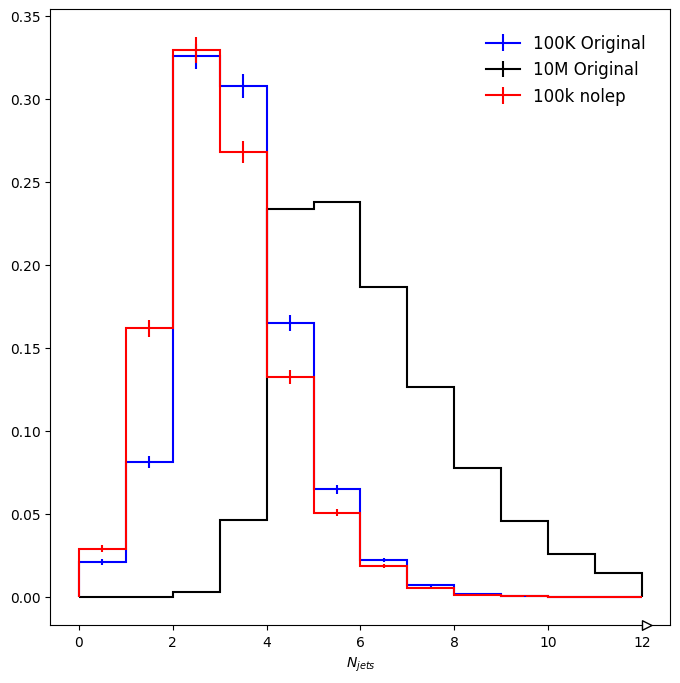

In [37]:
rwFracs = [0.25, 0.5, 0.75]
observable = "njets"
logy=True
weights = [weights_orig_z, weights_orig_highstat]
logx = obsDict[observable]["logx"]
xmin = obsDict[observable]["xmin"]
xmax = obsDict[observable]["xmax"]
ymin = obsDict[observable]["ymin"]
ymax = obsDict[observable]["ymax"]
nbins = obsDict[observable]["numbins"]
obs_str = obsDict[observable]["name"]
obs = obsDict[observable]["obs"]
obs_hs = obsDict_highstat[observable]["obs"]
sel = np.array(obsDict[observable]["sel"])
sel_hs = np.array(obsDict_highstat[observable]["sel"])
ratioLim = obsDict[observable]["ratioLim"]
units = obsDict[observable]["units"]

jets_other = ak.from_parquet("/users/lhay/NegativeWeights/zjj_NLO_100k_alljetsNOLEP.parquet")
obs_other = ak.num(jets_other.pt, axis=1)

print(np.shape(sel))
print(np.shape(weights_orig_highstat))
print(np.shape(obs))
if logx:
    bins = np.logspace(np.log10(xmin), np.log10(xmax), nbins)
    axis_o = hist.axis.Variable(bins,name="data",label="orig",)
    axis_rw = hist.axis.Variable(bins,name="data",label="reweighted",)
else:
    axis_o = hist.axis.Regular(nbins,xmin, xmax,name="data",label="orig",)
    axis_rw = hist.axis.Regular(nbins,xmin, xmax,name="data",label="orig",)
if sel is None:
    sel  = np.ones_like(weights_orig_highstat, dtype=bool)
fig, ax = plt.subplots(nrows=1,
                    ncols=1,
                    figsize=(8,8),)
h_orig = hist.Hist(
    axis_o,
    storage=hist.storage.Weight(), )
h_orig.fill(obs, weight = weights_orig_z)
h_orig = h_orig/h_orig.sum(flow=False).value
hep.histplot(h_orig, ax=ax, label = "100K Original", color='blue')
h_orig_hs = hist.Hist(
    axis_o,
    storage=hist.storage.Weight(), )
h_orig_hs.fill(obs_hs, weight = weights_orig_highstat)
h_orig_hs = h_orig_hs/h_orig_hs.sum(flow=False).value
hep.histplot(h_orig_hs, ax=ax, label = "10M Original", color='black')
h_orig2 = hist.Hist(
    axis_o,
    storage=hist.storage.Weight(), )
h_orig2.fill(obs_other, weight = weights_orig_z)
h_orig2 = h_orig2/h_orig2.sum(flow=False).value
hep.histplot(h_orig2, ax=ax, label = "100k nolep", color='red')
ax.legend(frameon=False, fontsize=12, loc="upper right", borderpad=1.0)
ax.set_xlabel(r"$N_{jets}$")